# Compare real data vs simulation for Abell 360 (a360)

Loads the merged AnaCal catalogs from two butler collections:
- `u/xiangchl/dp1/a360_anacal_coadd` — real ComCam coadds (MeasureCoaddsPipe)
- `u/xiangchl/dp1/a360_anacal_sim_80_0` — image simulation under the same systematics

Bands available: g, r, i, z. Magnitude flux source is selectable via
`FLUX_KIND` (`fpfs1`, `gauss0`, `gauss2`, `gauss4`).

In [22]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

from astropy.table import Table, vstack
from lsst.daf.butler import Butler

BIGGER_SIZE = 20
plt.rc("font", size=BIGGER_SIZE)
plt.rc("axes", titlesize=BIGGER_SIZE)
plt.rc("axes", labelsize=BIGGER_SIZE)
plt.rc("xtick", labelsize=BIGGER_SIZE)
plt.rc("ytick", labelsize=BIGGER_SIZE)
plt.rc("legend", fontsize=BIGGER_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

In [23]:

FLUX_KIND = "fpfs1"


def flux_col(band: str, kind: str = FLUX_KIND) -> str:
    return f"{band}_flux_{kind}"


def flux_to_mag(flux, mag_zero=31.4):
    flux = np.asarray(flux)
    return mag_zero - 2.5 * np.log10(flux)


print(f"Using flux source: {FLUX_KIND}  (column pattern: '{{band}}_flux_{FLUX_KIND}')")

Using flux source: fpfs1  (column pattern: '{band}_flux_fpfs1')


In [24]:
REPO = "/global/cfs/cdirs/lsst/production/gen3/rubin/DP1/repo/butler.yaml"
COLL_DATA = "u/xiangchl/dp1/a360_anacal_coadd/20260513T081515Z"
COLL_SIM = "u/xiangchl/dp1/a360_anacal_sim_80_0"

# Per-patch anacal_catalogs (have per-band shapelet moments + ra/dec + flux).
DSTYPE_DATA = "deep_coadd_anacal_catalog"          # measure_pipeline_coadd outputs
DSTYPE_SIM = "deep_coadd_cell_80_0_anacal_catalog" # measure_pipeline_sim outputs (outName=deep_coadd_cell_80_0)

butler_data = Butler(REPO, collections=COLL_DATA)
butler_sim = Butler(REPO, collections=COLL_SIM)


def load_anacal(butler, dataset_type):
    """vstack all per-patch anacal_catalog refs and keep only is_primary=True rows."""
    refs = list(set(butler.registry.queryDatasets(dataset_type)))
    if len(refs) == 0:
        raise RuntimeError(f"no {dataset_type} datasets found in {butler.collections}")
    tables = [Table(butler.get(ref)) for ref in refs]
    cat = vstack(tables)
    if "is_primary" in cat.colnames:
        cat = cat[cat["is_primary"]]
    return cat


data = load_anacal(butler_data, DSTYPE_DATA)
sim = load_anacal(butler_sim, DSTYPE_SIM)
print(f"data rows (is_primary): {len(data)}, sim rows (is_primary): {len(sim)}")

for b in "griz":
    if flux_col(b) not in data.colnames:
        raise KeyError(f"column {flux_col(b)!r} not in real catalog (FLUX_KIND={FLUX_KIND})")
    if flux_col(b) not in sim.colnames:
        raise KeyError(f"column {flux_col(b)!r} not in sim catalog (FLUX_KIND={FLUX_KIND})")

data rows (is_primary): 135392, sim rows (is_primary): 190375


In [25]:
def _select(t):
    return (
        ((31.4 - 2.5 * np.log10(t[flux_col("i")])) < 24.5)
        & ((31.4 - 2.5 * np.log10(t[flux_col("g")])) < 26.0)
        & ((31.4 - 2.5 * np.log10(t[flux_col("r")])) < 25.0)
        & ((31.4 - 2.5 * np.log10(t[flux_col("z")])) < 25.0)
        & ((t["i_fpfs1_m00"] + t["i_fpfs1_m20"]) / t["i_fpfs1_m00"] > 0.08)
    )


sel1 = _select(data)
sel2 = _select(sim)
print(f"selected: data={sel1.sum()}, sim={sel2.sum()}")

selected: data=59242, sim=63045


/tmp/ipykernel_1107645/3939814608.py:3: RuntimeWarning: invalid value encountered in log10
  ((31.4 - 2.5 * np.log10(t[flux_col("i")])) < 24.5)
/tmp/ipykernel_1107645/3939814608.py:4: RuntimeWarning: invalid value encountered in log10
  & ((31.4 - 2.5 * np.log10(t[flux_col("g")])) < 26.0)
/tmp/ipykernel_1107645/3939814608.py:5: RuntimeWarning: invalid value encountered in log10
  & ((31.4 - 2.5 * np.log10(t[flux_col("r")])) < 25.0)
/tmp/ipykernel_1107645/3939814608.py:6: RuntimeWarning: invalid value encountered in log10
  & ((31.4 - 2.5 * np.log10(t[flux_col("z")])) < 25.0)


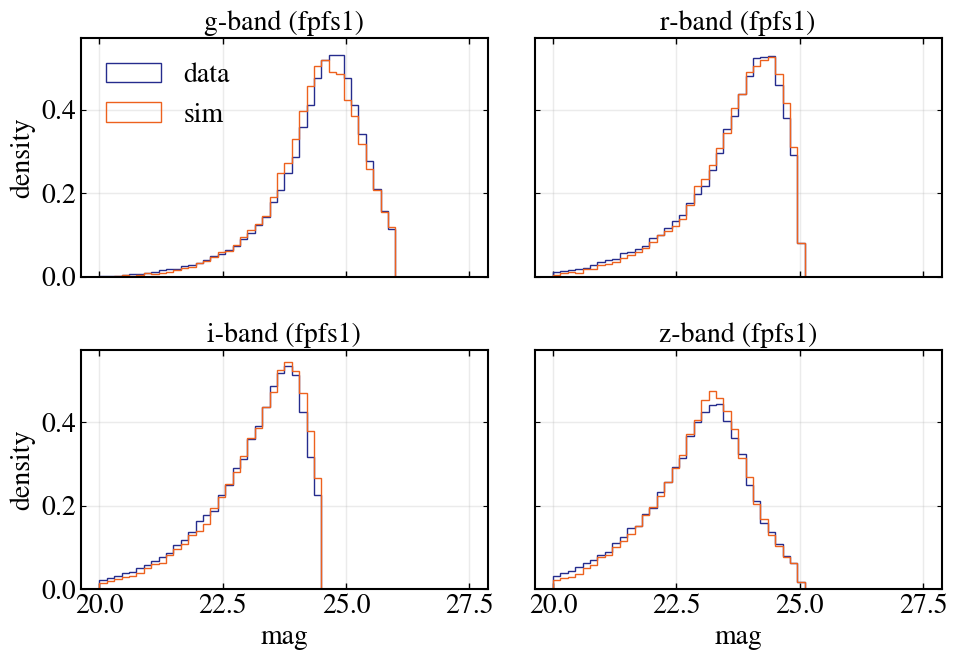

In [26]:
bands = "griz"
mag_zero = 31.4
bins = 50
mag_range = (20, 27.5)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, b in enumerate(bands):
    ax = axes[i]

    f_data = np.asarray(data[flux_col(b)])[sel1]
    f_sim = np.asarray(sim[flux_col(b)])[sel2]

    m_data = np.isfinite(f_data) & (f_data > 0)
    m_sim = np.isfinite(f_sim) & (f_sim > 0)

    mag_data = flux_to_mag(f_data[m_data], mag_zero=mag_zero)
    mag_sim = flux_to_mag(f_sim[m_sim], mag_zero=mag_zero)

    ax.hist(mag_data, histtype="step", bins=bins, density=True, range=mag_range, label="data")
    ax.hist(mag_sim, histtype="step", bins=bins, density=True, range=mag_range, label="sim")

    ax.set_title(f"{b}-band ({FLUX_KIND})")
    ax.grid(True, alpha=0.25)

    if i % 2 == 0:
        ax.set_ylabel("density")
    if i >= 2:
        ax.set_xlabel("mag")

axes[0].legend(loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

In [27]:
dd = {}
ss = {}
for b in bands:
    f_data = np.asarray(data[flux_col(b)])[sel1]
    f_sim = np.asarray(sim[flux_col(b)])[sel2]

    dd[b] = mag_zero - 2.5 * np.log10(f_data)
    ss[b] = mag_zero - 2.5 * np.log10(f_sim)

In [28]:
class corner_plot:
    def __init__(self, xrange, yrange, bins=30, xlabel="x", ylabel="y", xlim=None, ylim=None):
        fig = plt.figure(figsize=(8, 8))
        gs = fig.add_gridspec(4, 4, wspace=0.05, hspace=0.05)
        self.ax_2d = fig.add_subplot(gs[1:4, 0:3])
        self.ax_2d.set_xlabel(xlabel)
        self.ax_2d.set_ylabel(ylabel)

        self.ax_top = fig.add_subplot(gs[0, 0:3], sharex=self.ax_2d)
        self.ax_top.set_ylabel("PDF")
        self.ax_top.tick_params(axis="x", labelbottom=False)

        self.ax_right = fig.add_subplot(gs[1:4, 3], sharey=self.ax_2d)
        self.ax_right.set_xlabel("PDF")
        self.ax_right.tick_params(axis="y", labelleft=False)

        self.range_2d = [xrange, yrange]
        self.range_x = xrange
        self.range_y = yrange
        self.bins = bins

        if xlim is None:
            xlim = self.range_x
        if ylim is None:
            ylim = self.range_y
        self.ax_2d.set_xlim(xlim)
        self.ax_2d.set_ylim(ylim)
        self.ax_top.set_xlim(xlim)
        self.ax_right.set_ylim(ylim)

    def make_plot(self, x_array, y_array, linestyles="-", levels=[0.1, 0.3, 0.6]):
        hist, xedges, yedges = np.histogram2d(
            x=x_array, y=y_array, bins=self.bins,
            range=self.range_2d, density=True,
        )
        xcenters = 0.5 * (xedges[:-1] + xedges[1:])
        ycenters = 0.5 * (yedges[:-1] + yedges[1:])
        X, Y = np.meshgrid(xcenters, ycenters)

        self.ax_2d.contour(
            X, Y, hist.T, levels=levels,
            colors="black", linestyles=linestyles,
        )
        self.ax_top.hist(
            x_array, bins=self.bins, histtype="step", color="black",
            range=self.range_x, density=True, ls=linestyles,
        )
        self.ax_right.hist(
            y_array, bins=self.bins, histtype="step", color="black",
            range=self.range_y, density=True,
            ls=linestyles, orientation="horizontal",
        )
        plt.tight_layout()

/tmp/ipykernel_1107645/3419352203.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


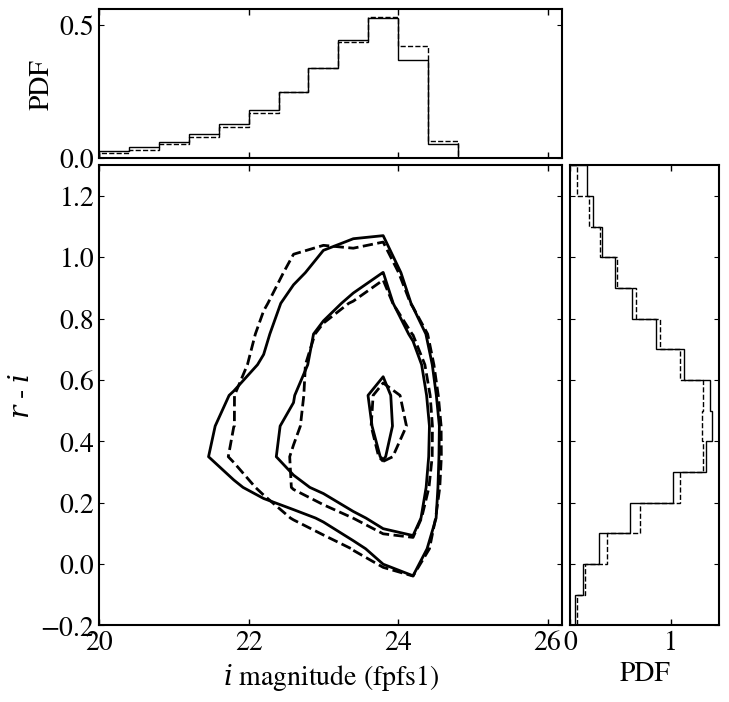

In [29]:
plt.close()
xrange = [20.0, 26.0]
yrange = [-0.2, 1.3]
xlabel = rf"$i$ magnitude ({FLUX_KIND})"
ylabel = r"$r$ - $i$"

corp = corner_plot(
    xrange=xrange, yrange=yrange, bins=15, xlabel=xlabel, ylabel=ylabel,
    xlim=[20, 26.2], ylim=[-0.2, 1.3],
)

x_array = ss["i"]
y_array = ss["r"] - ss["i"]

x_array_d = dd["i"]
y_array_d = dd["r"] - dd["i"]

corp.make_plot(x_array=x_array_d, y_array=y_array_d, linestyles="-", levels=[0.15, 0.3, 0.65])
corp.make_plot(x_array=x_array, y_array=y_array, linestyles="--", levels=[0.15, 0.3, 0.65])

/tmp/ipykernel_1107645/3419352203.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


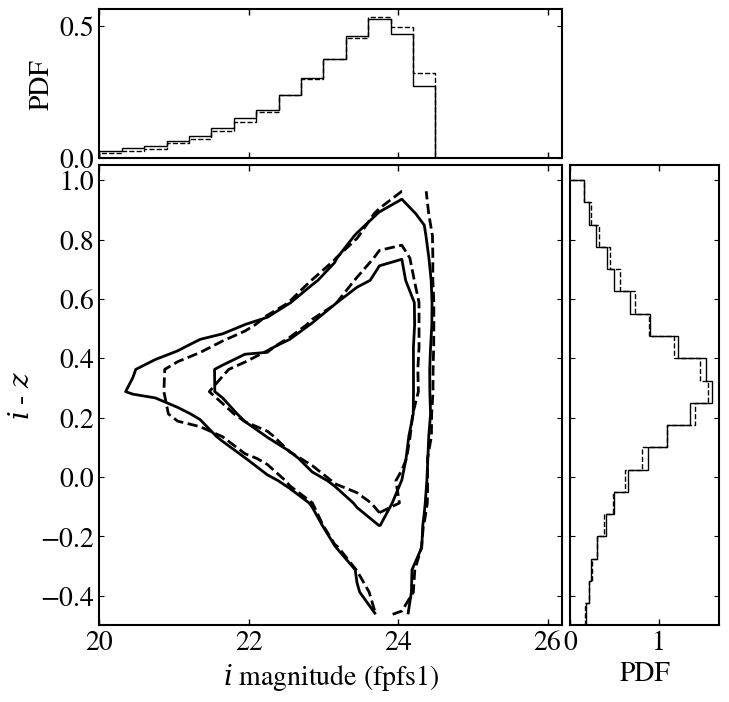

In [30]:
plt.close()
xrange = [20.0, 26.0]
yrange = [-0.5, 1.0]
xlabel = rf"$i$ magnitude ({FLUX_KIND})"
ylabel = r"$i$ - $z$"

corp = corner_plot(
    xrange=xrange, yrange=yrange, bins=20, xlabel=xlabel, ylabel=ylabel,
    xlim=[20, 26.2], ylim=[-0.5, 1.05],
)

x_array = ss["i"]
y_array = ss["i"] - ss["z"]

x_array_d = dd["i"]
y_array_d = dd["i"] - dd["z"]

corp.make_plot(x_array=x_array_d, y_array=y_array_d, linestyles="-", levels=[0.15, 0.3, 0.65])
corp.make_plot(x_array=x_array, y_array=y_array, linestyles="--", levels=[0.15, 0.3, 0.65])

/tmp/ipykernel_1107645/3419352203.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


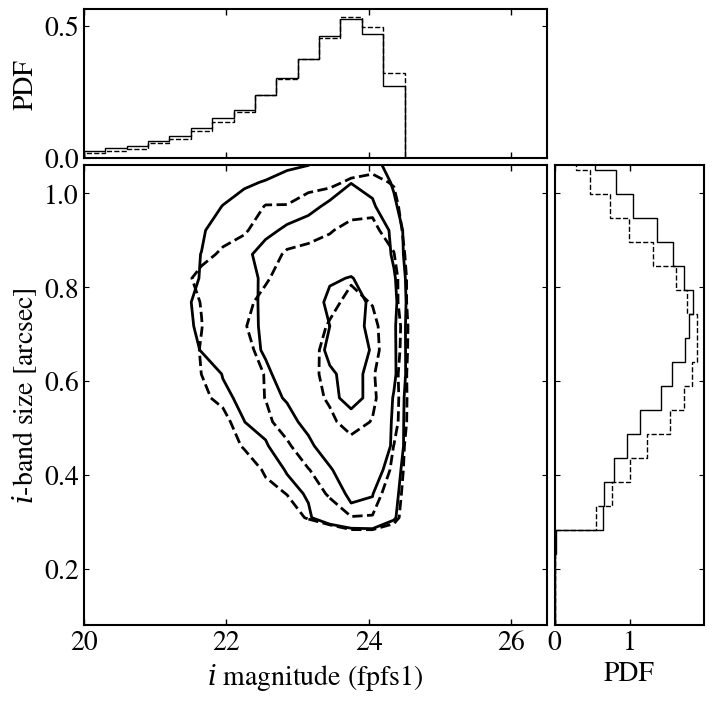

In [31]:
plt.close()
xrange = [20.0, 26.0]
yrange = [0.08, 1.1]
xlabel = rf"$i$ magnitude ({FLUX_KIND})"
ylabel = r"$i$-band size [arcsec]"
corp = corner_plot(
    xrange=xrange, yrange=yrange, bins=20, xlabel=xlabel, ylabel=ylabel,
    xlim=[20.0, 26.5], ylim=[0.08, 1.06],
)

# i-band size from the per-patch anacal_catalog (per-band shapelet moments).
_i_data = dd["i"]
_i_sim = ss["i"]
_size_data = ((data["i_fpfs1_m00"][sel1] + data["i_fpfs1_m20"][sel1]) / data["i_fpfs1_m00"][sel1]) ** 0.5
_size_sim = ((sim["i_fpfs1_m00"][sel2] + sim["i_fpfs1_m20"][sel2]) / sim["i_fpfs1_m00"][sel2]) ** 0.5

corp.make_plot(x_array=_i_data, y_array=_size_data, linestyles="-", levels=[0.2, 0.4, 0.8])
corp.make_plot(x_array=_i_sim, y_array=_size_sim, linestyles="--", levels=[0.2, 0.4, 0.8])

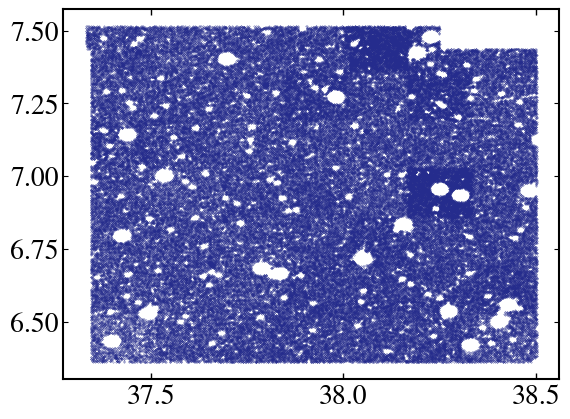

In [32]:
plt.scatter(sim["ra"], sim["dec"], s=0.05)

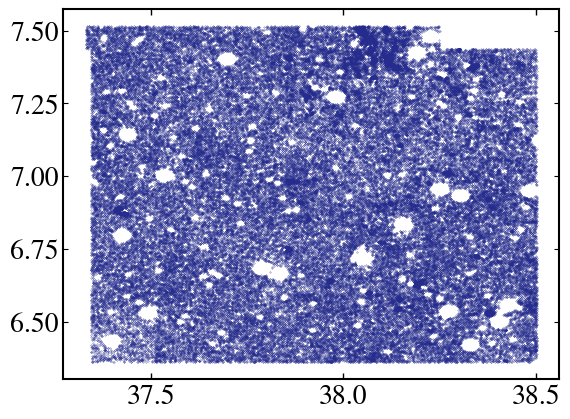

In [33]:
plt.scatter(data["ra"], data["dec"], s=0.05)